# Cameroon CO2 emissions forecasting

Compare persistence, local drift, Ridge and random forest models on real annual Cameroon emissions using validation-based model choice and rolling holdout evaluation.

**Data provenance and limitations:** 65 annual observations; model settings are fixed rather than extensively tuned. Test results may favour a baseline. Forecasts are estimates, not known emissions, and do not support causal or clinical claims.

This notebook runs the repository analysis and displays its saved results.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
from analysis import run
metrics = run()
print(json.dumps(metrics, indent=2))

{
  "country": "Cameroon",
  "unit": "Mt CO2 / year",
  "first_year": 1960,
  "last_observed_year": 2024,
  "observed_years": 65,
  "validation_years": [
    2005,
    2014
  ],
  "test_years": [
    2015,
    2024
  ],
  "selected_on_validation": "persistence",
  "selected_test_scores": {
    "model": "persistence",
    "MAE_mtco2": 0.2420999999999996,
    "RMSE_mtco2": 0.3834958930679697,
    "n_years": 10
  },
  "all_test_scores": [
    {
      "model": "persistence",
      "MAE_mtco2": 0.2420999999999996,
      "RMSE_mtco2": 0.3834958930679697,
      "n_years": 10
    },
    {
      "model": "local_drift",
      "MAE_mtco2": 0.32934999999999964,
      "RMSE_mtco2": 0.4694251005219038,
      "n_years": 10
    },
    {
      "model": "ridge",
      "MAE_mtco2": 0.5396694951102956,
      "RMSE_mtco2": 0.7600736883792323,
      "n_years": 10
    },
    {
      "model": "random_forest",
      "MAE_mtco2": 0.5512938573967716,
      "RMSE_mtco2": 0.8380144959951749,
      "n_years": 10
  

forecast_and_backtest.png


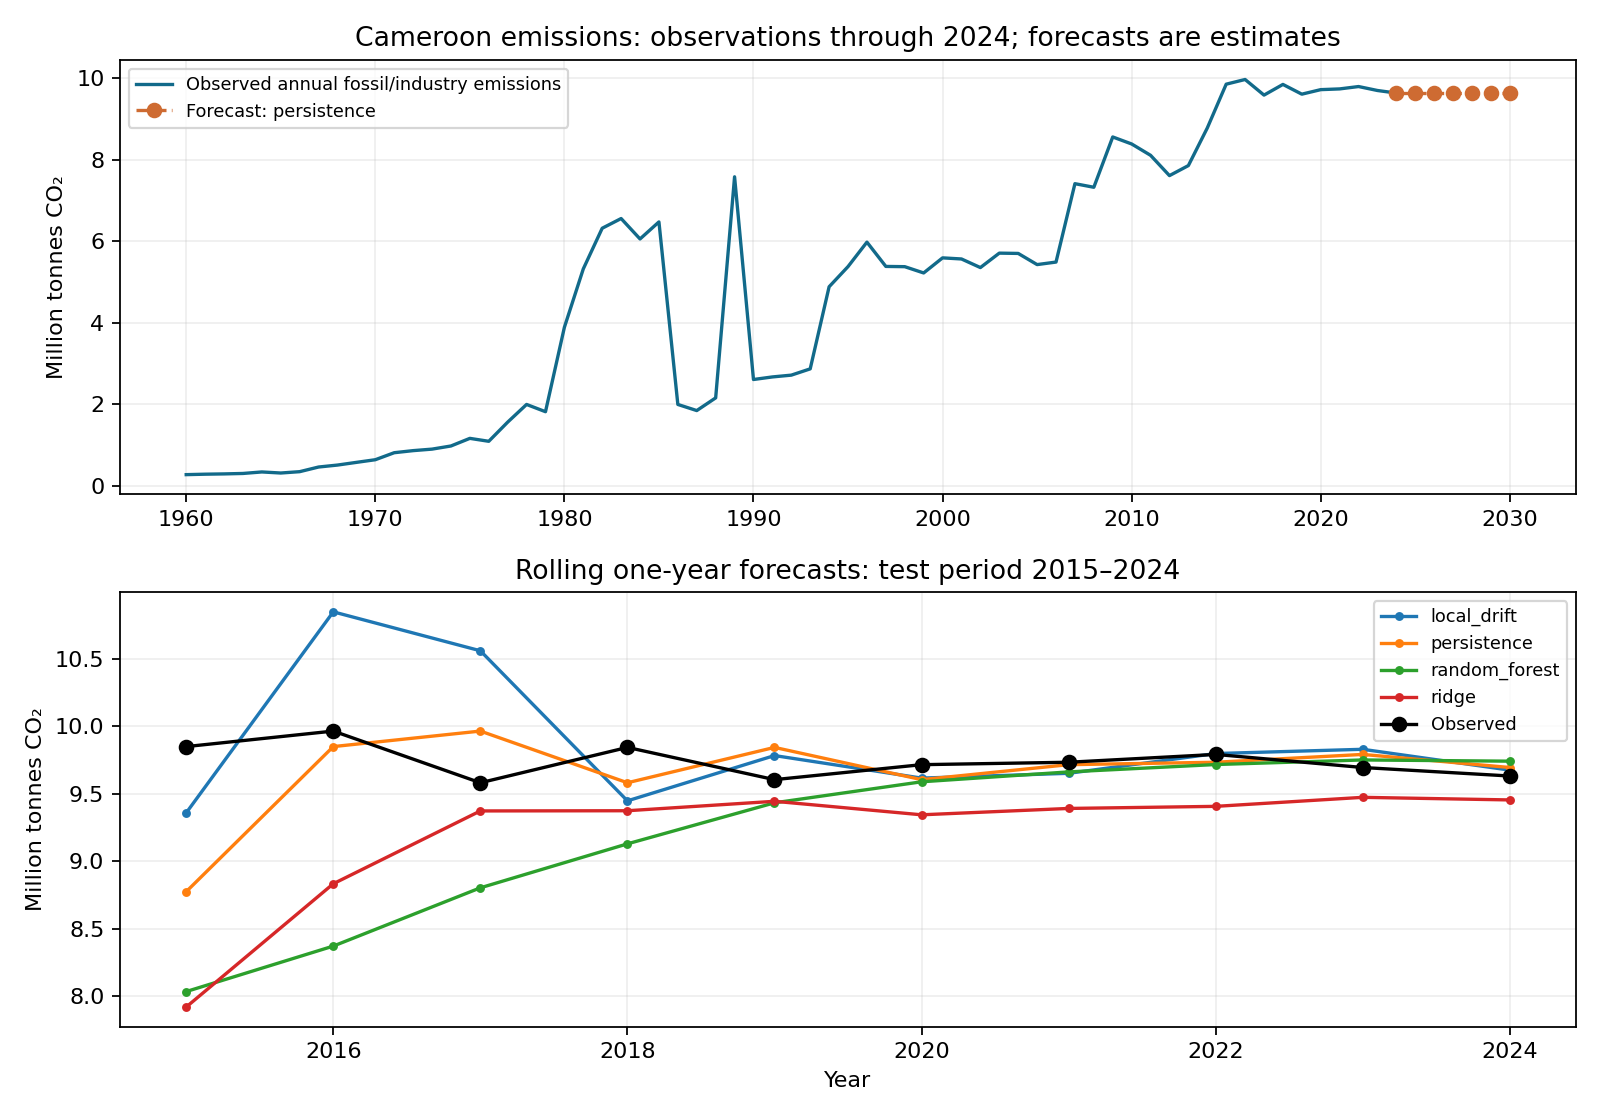

In [2]:
for path in sorted(Path('results').glob('*.png')):
    print(path.name)
    display(Image(filename=str(path)))

In [3]:
for path in sorted(Path('results').glob('*.csv')):
    print(path.name)
    display(pd.read_csv(path).head(10))

forecasts_2025_2030.csv
test_predictions.csv
test_scores.csv
validation_predictions.csv
validation_scores.csv


,year,forecast_mtco2,model
0,2025,9.632,persistence
1,2026,9.632,persistence
2,2027,9.632,persistence
3,2028,9.632,persistence
4,2029,9.632,persistence
5,2030,9.632,persistence


,year,model,actual_mtco2,prediction_mtco2,train_last_year
0,2015,persistence,9.850,8.775000,2014
1,2015,local_drift,9.850,9.359000,2014
2,2015,ridge,9.850,7.920291,2014
3,2015,random_forest,9.850,8.034671,2014
4,2016,persistence,9.965,9.850000,2015
5,2016,local_drift,9.965,10.848500,2015
6,2016,ridge,9.965,8.833588,2015
7,2016,random_forest,9.965,8.371615,2015
8,2017,persistence,9.582,9.965000,2016
9,2017,local_drift,9.582,10.560000,2016


,model,MAE_mtco2,RMSE_mtco2,n_years
0,persistence,0.242100,0.383496,10
1,local_drift,0.329350,0.469425,10
2,ridge,0.539669,0.760074,10
3,random_forest,0.551294,0.838014,10


,year,model,actual_mtco2,prediction_mtco2,train_last_year
0,2005,persistence,5.424,5.698000,2004
1,2005,local_drift,5.424,5.871500,2004
2,2005,ridge,5.424,5.217109,2004
3,2005,random_forest,5.424,5.528913,2004
4,2006,persistence,5.486,5.424000,2005
5,2006,local_drift,5.486,5.283500,2005
6,2006,ridge,5.486,5.130494,2005
7,2006,random_forest,5.486,5.388667,2005
8,2007,persistence,7.409,5.486000,2006
9,2007,local_drift,7.409,5.380000,2006


,model,MAE_mtco2,RMSE_mtco2,n_years
0,persistence,0.569700,0.810729,10
1,local_drift,0.758500,0.917063,10
2,ridge,0.922798,1.175052,10
3,random_forest,1.384762,1.766836,10


## Interpretation and next steps

65 annual observations; model settings are fixed rather than extensively tuned. Test results may favour a baseline. Forecasts are estimates, not known emissions, and do not support causal or clinical claims.

Use `results/metrics.json` and the displayed tables to report actual findings. Consult `REVIEW_GUIDE.md` before using the CV wording: **Developed a reproducible Cameroon CO2 forecasting study using real emissions data, lagged predictors, rolling evaluation and baseline comparisons.**

### Observed result

Used **65 annual observations, 1960–2024**. Persistence was selected on the 2005–2014 validation period and also gave the lowest 2015–2024 test RMSE: **0.3835 Mt CO2**, compared with **0.7601** for Ridge and **0.8380** for random forest. Fixed model settings and the small dataset limit conclusions. The six-year projection stays at the last observed 2024 value, **9.632 Mt CO2/year**; it is an estimate, not an observation.